<a href="https://colab.research.google.com/github/chaiyawat19/DataScinceLab/blob/main/Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.3 MB/s eta 0:00:00


In [ ]:
!pip install statsmodels

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DataSciProject2-68/Tourist.csv')
#เพิ่มshortcutไปMyDriveของตัวเองด้วย
df

,Year,Province,Country,Month,Count
0,2556,กระบี่,Brunei,1,84
1,2556,กระบี่,Brunei,2,72
2,2556,กระบี่,Brunei,3,68
3,2556,กระบี่,Brunei,4,0
4,2556,กระบี่,Brunei,5,9
...,...,...,...,...,...
421339,2567,แม่ฮ่องสอน,United Kingdom,8,2262
421340,2567,แม่ฮ่องสอน,United Kingdom,9,2330
421341,2567,แม่ฮ่องสอน,United Kingdom,10,2624
421342,2567,แม่ฮ่องสอน,United Kingdom,11,3338


In [ ]:
df["Country"].nunique()

38

In [ ]:
df["Country"].unique()

array(['     Brunei', '     Cambodia', '     Indonesia', '     Laos',
       '     Malaysia', '     Myanmar', '     Philippines',
       '     Singapore', '     Vietnam', 'Africa', 'Australia', 'Austria',
       'Belgium', 'Canada', 'China', 'Denmark', 'East Europe', 'Finland',
       'France', 'Germany', 'Hong Kong', 'India', 'Israel', 'Italy',
       'Japan', 'Korea', 'Middle East', 'Netherlands', 'New Zealand',
       'Norway', 'Russia', 'Spain', 'Sweden', 'Switzerland', 'Taiwan',
       'Thai', 'USA', 'United Kingdom'], dtype=object)

In [ ]:
tourist = df.groupby(['Year','Month'])['Count'].sum().reset_index()
tourist['Year_AD'] = tourist['Year'] - 543

tourist['Date'] = pd.to_datetime(
    tourist['Year_AD'].astype(str) + '-' + tourist['Month'].astype(str)
)

tourist = tourist.sort_values('Date')
tourist.set_index('Date', inplace=True)

actual_data = tourist['Count']
tourist

,Year,Month,Count,Year_AD
Date,,,,
2013-01-01,2556,1,10577570,2013
2013-02-01,2556,2,10178710,2013
2013-03-01,2556,3,9947041,2013
2013-04-01,2556,4,10015904,2013
2013-05-01,2556,5,9509530,2013
...,...,...,...,...
2024-08-01,2567,8,14115024,2024
2024-09-01,2567,9,13307990,2024
2024-10-01,2567,10,14074675,2024


<Axes: xlabel='Date'>

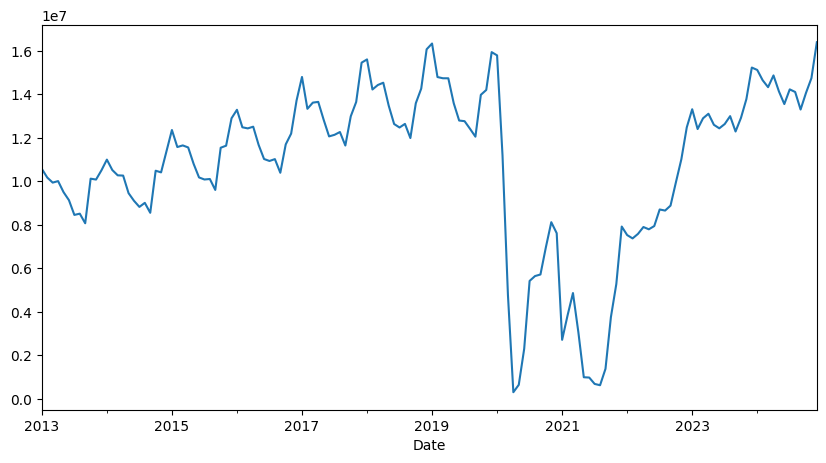

In [ ]:
tourist['Count'].plot(figsize=(10,5))

# **SARIMA**

In [ ]:
train = actual_data[:'2023']
test = actual_data['2024':]

In [ ]:
from pmdarima import auto_arima
auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=4057.748, Time=1.07 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=4371.603, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=4083.100, Time=0.36 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=4278.226, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=4658.832, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=4064.831, Time=0.43 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=4059.772, Time=0.69 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=4059.632, Time=2.49 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=4059.748, Time=3.77 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=4074.251, Time=1.06 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=4063.082, Time=2.71 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=4058.665, Time=1.95 sec
 ARIMA(2,0,2)(2,0,2)[12] intercept   : AIC=inf, Time=3.01 sec
 ARIMA(1,0,2)(1,0,1)[12] intercept   : AIC=4058.080, Time=0.44 sec
 ARIMA(2,0,1)(1,0,1)[12]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train,
                order=(0,1,1),
                seasonal_order=(1,0,1,12))

result = model.fit()
pred = result.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
mae = mean_absolute_error(test, pred)
mse = mean_squared_error(test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(test, pred)
mape = mean_absolute_percentage_error(test, pred)
mape_p = mean_absolute_percentage_error(test, pred) * 100
accuracy = (1 - mape) * 100


print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")
print(f"MAPE: {mape_p:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

MAE: 370009.61
RMSE: 458483.63
R2: 0.64
MAPE: 2.60%
Accuracy: 97.40%


In [ ]:
srm = SARIMAX(actual_data,
                      order=(0,1,1),
                      seasonal_order=(1,0,1,12))

srm_model = srm.fit()
forecast = srm_model.forecast(steps=72)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
srm_model.save('/content/srm_model.keras')

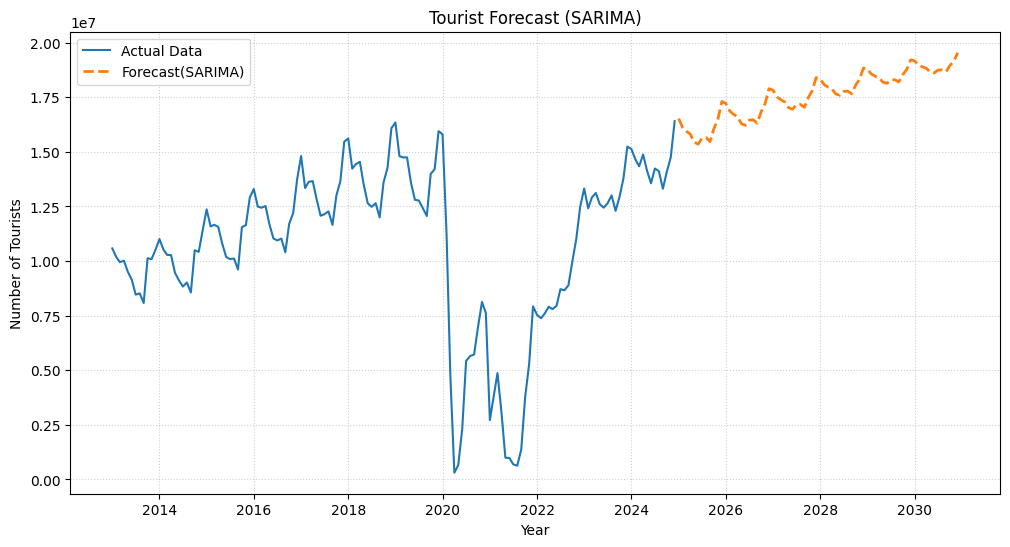

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual_data.index, actual_data, label='Actual Data')
plt.plot(forecast.index, forecast, label='Forecast(SARIMA)', linestyle='--', linewidth=2,)

plt.title('Tourist Forecast (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Number of Tourists')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

# **Random Forest Regressor**

In [ ]:
tourist

,Year,Month,Count,Year_AD
Date,,,,
2013-01-01,2556,1,10577570,2013
2013-02-01,2556,2,10178710,2013
2013-03-01,2556,3,9947041,2013
2013-04-01,2556,4,10015904,2013
2013-05-01,2556,5,9509530,2013
...,...,...,...,...
2024-08-01,2567,8,14115024,2024
2024-09-01,2567,9,13307990,2024
2024-10-01,2567,10,14074675,2024


In [ ]:
from sklearn.ensemble import RandomForestRegressor

train = tourist[tourist['Year_AD'] <= 2023]
test = tourist[tourist['Year_AD'] >= 2024]

rfx_train = train[['Year','Month']]
rfy_train = train['Count']

rfx_test = test[['Year','Month']]
rfy_test = test['Count']

rfr = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rfr.fit(rfx_train, rfy_train)
rfy_pred = rfr.predict(rfx_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
rf_mae = mean_absolute_error(rfy_test, rfy_pred)
rf_mse = mean_squared_error(rfy_test, rfy_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(rfy_test, rfy_pred)
rf_mape = mean_absolute_percentage_error(rfy_test, rfy_pred)
rf_mape_p = mean_absolute_percentage_error(rfy_test, rfy_pred) * 100
rf_accuracy = (1 - rf_mape) * 100


print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2: {rf_r2:.2f}")
print(f"MAPE: {rf_mape_p:.2f}%")
print(f"Accuracy: {rf_accuracy:.2f}%")

MAE: 1483245.14
RMSE: 1535804.15
R2: -2.99
MAPE: 10.18%
Accuracy: 89.82%


In [ ]:
last_year = df['Year'].max()
last_month = df[df['Year']==last_year]['Month'].max()

rf_years = []
rf_months = []

y = last_year
m = last_month

for _ in range(72):
    m += 1
    if m > 12:
        m = 1
        y += 1
    rf_years.append(y)
    rf_months.append(m)

rf_df = pd.DataFrame({
    'Year': rf_years,
    'Month': rf_months
})

rf_pred = rfr.predict(rf_df)

rf_df['Count'] = rf_pred.round().astype(int)
rf_df['Year_AD'] = rf_df['Year'] - 543

rf_df['Date'] = pd.to_datetime(
    rf_df['Year_AD'].astype(str) + '-' + rf_df['Month'].astype(str)
)

rf_df.set_index('Date', inplace=True)

In [ ]:
import joblib
joblib.dump(rfr, '/content/rfr_model.pkl')

['/content/rfr_model.pkl']

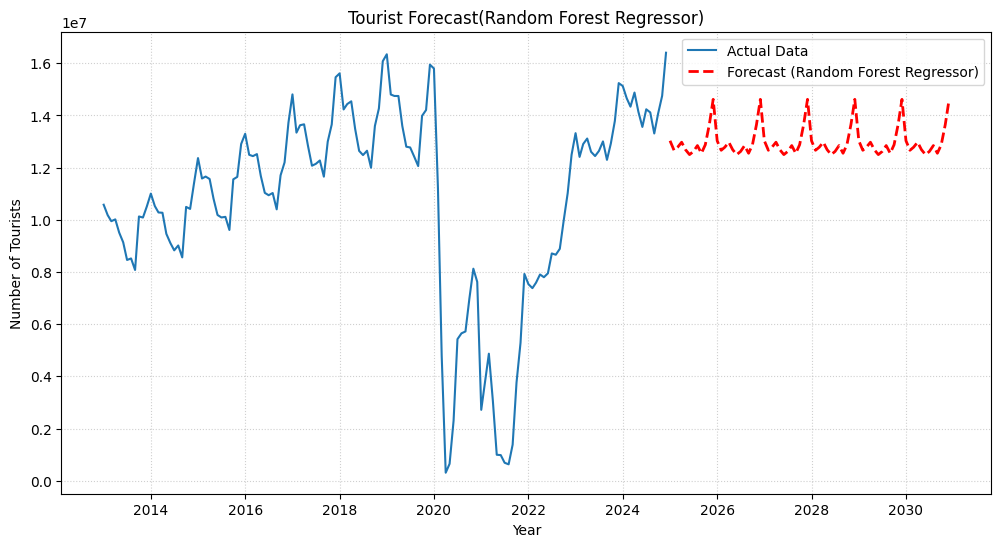

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(actual_data.index, actual_data, label='Actual Data')

plt.plot(rf_df.index, rf_df['Count'],
         label='Forecast (Random Forest Regressor)',
         linestyle='--',
         color='red',
         linewidth=2)

plt.title('Tourist Forecast(Random Forest Regressor)')
plt.xlabel('Year')
plt.ylabel('Number of Tourists')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

# **Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

train = tourist[tourist['Year_AD'] <= 2023]
test = tourist[tourist['Year_AD'] >= 2024]

dtx_train = train[['Year','Month']]
dty_train = train['Count']

dtx_test = test[['Year','Month']]
dty_test = test['Count']

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(dtx_train, dty_train)
dty_pred = dt.predict(dtx_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
dt_mae = mean_absolute_error(dty_test, dty_pred)
dt_mse = mean_squared_error(dty_test, dty_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(dty_test, dty_pred)
dt_mape = mean_absolute_percentage_error(dty_test, dty_pred)
dt_mape_p = mean_absolute_percentage_error(dty_test, dty_pred) * 100
dt_accuracy = (1 - dt_mape) * 100


print(f"MAE: {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R2: {dt_r2:.2f}")
print(f"MAPE: {dt_mape_p:.2f}%")
print(f"Accuracy: {dt_accuracy:.2f}%")

MAE: 1407876.75
RMSE: 1457132.51
R2: -2.59
MAPE: 9.72%
Accuracy: 90.28%


In [ ]:
last_year = df['Year'].max()
last_month = df[df['Year']==last_year]['Month'].max()

dt_years = []
dt_months = []

y = last_year
m = last_month

for _ in range(72):

    m += 1

    if m > 12:
        m = 1
        y += 1

    dt_years.append(y)
    dt_months.append(m)

dt_df = pd.DataFrame({
    'Year': dt_years,
    'Month': dt_months
})

pred_dt = dt.predict(dt_df)

dt_df['Count'] = pred_dt.round().astype(int)

dt_df['Year_AD'] = dt_df['Year'] - 543

dt_df['Date'] = pd.to_datetime(
    dt_df['Year_AD'].astype(str) + '-' + dt_df['Month'].astype(str)
)

dt_df.set_index('Date', inplace=True)

In [ ]:
joblib.dump(dt, '/content/dt_model.pkl')

['/content/dt_model.pkl']

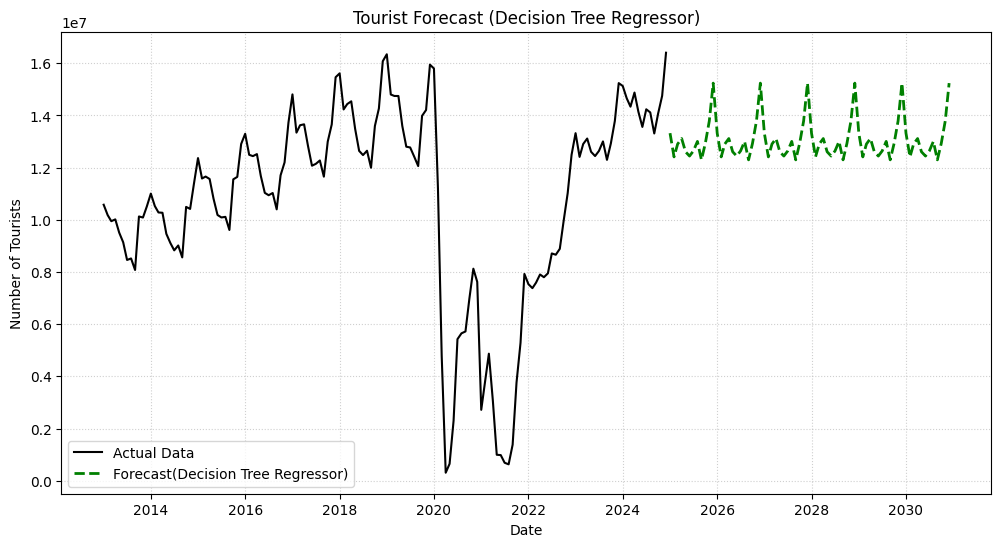

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual_data.index, actual_data,
         color='black',
         label='Actual Data')

plt.plot(dt_df.index, dt_df['Count'],
         linestyle='--',
         color='green',
         linewidth=2,
         label='Forecast(Decision Tree Regressor)')

plt.title('Tourist Forecast (Decision Tree Regressor)')
plt.xlabel('Date')
plt.ylabel('Number of Tourists')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

# **กราฟเปรียบเทียบ**


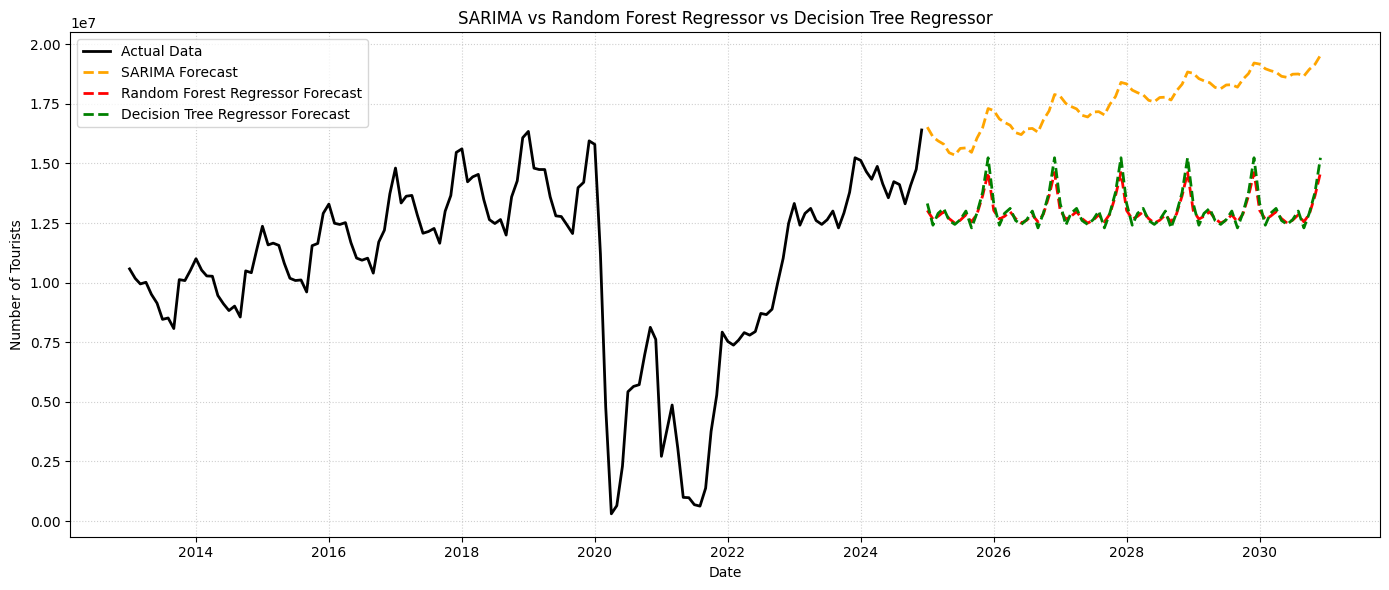

In [ ]:
plt.figure(figsize=(14,6))

#ข้อมูลจริง
plt.plot(actual_data.index, actual_data,
         color='black',
         linewidth=2,
         label='Actual Data')

#SARIMA
plt.plot(forecast.index, forecast,
         linestyle='--',
         color='orange',
         linewidth=2,
         label='SARIMA Forecast')

#Random Forest
plt.plot(rf_df.index, rf_df['Count'],
         linestyle='--',
         color='red',
         linewidth=2,
         label='Random Forest Regressor Forecast')

#Decision Tree Regressor
plt.plot(dt_df.index, dt_df['Count'],
         linestyle='--',
         color='green',
         linewidth=2,
         label='Decision Tree Regressor Forecast')

plt.title('SARIMA vs Random Forest Regressor vs Decision Tree Regressor')
plt.xlabel('Date')
plt.ylabel('Number of Tourists')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()